# Data Cleaning | Data Visualization | Preprocessing | Analysis

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shaistashahid/freelancer-income-vs-skills/freelancer_earnings - freelancer_earnings_vs_skillstack_dataset.csv


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
freelancer= pd.read_csv('/kaggle/input/datasets/shaistashahid/freelancer-income-vs-skills/freelancer_earnings - freelancer_earnings_vs_skillstack_dataset.csv')

In [4]:
freelancer.head(5)

,freelancer_id,category,primary_skills,years_experience,experience_level,region,country,education,hourly_rate_usd,annual_income_usd,primary_platform
0,FL0001,AI/ML Engineering,"Computer Vision, TensorFlow, Data Science",1.6,junior,Middle East,Israel,Master,66.41,"$58,873.61",Direct Client
1,FL0002,Backend Development,"PHP, Ruby, Go",8.3,senior,Middle East,UAE,Bootcamp,112.79,"$108,183.05",Freelancer
2,FL0003,UI/UX Design,"Sketch, Wireframing, Adobe XD",3.6,mid,North America,US,Self-taught,94.21,"$88,681.22",Freelancer
3,FL0004,DevOps,"Kubernetes, Terraform, AWS",2.3,mid,North America,US,Self-taught,118.87,"$109,229.42",Upwork
4,FL0005,DevOps,"Azure, Docker, Kubernetes",8.8,senior,Latin America,Mexico,Self-taught,82.76,"$66,298.22",LinkedIn


In [5]:
# freelancer.sample(10)

In [6]:
freelancer.shape

(500, 11)

In [7]:
# freelancer.isna().sum()[freelancer.isna().sum()> 0]
freelancer.isna().sum()

freelancer_id        0
category             0
primary_skills       0
years_experience     0
experience_level     0
region               0
country              0
education            0
hourly_rate_usd      0
annual_income_usd    0
primary_platform     0
dtype: int64

In [8]:
freelancer.describe()

,years_experience,hourly_rate_usd
count,500.000000,500.000000
mean,5.850000,97.149820
std,2.934779,52.697831
min,0.500000,17.280000
25%,3.600000,55.182500
50%,5.600000,84.445000
75%,7.800000,130.497500
max,14.000000,281.470000


In [9]:
freelancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   freelancer_id      500 non-null    object 
 1   category           500 non-null    object 
 2   primary_skills     500 non-null    object 
 3   years_experience   500 non-null    float64
 4   experience_level   500 non-null    object 
 5   region             500 non-null    object 
 6   country            500 non-null    object 
 7   education          500 non-null    object 
 8   hourly_rate_usd    500 non-null    float64
 9   annual_income_usd  500 non-null    object 
 10  primary_platform   500 non-null    object 
dtypes: float64(2), object(9)
memory usage: 43.1+ KB


In [10]:
freelancer.dtypes

freelancer_id         object
category              object
primary_skills        object
years_experience     float64
experience_level      object
region                object
country               object
education             object
hourly_rate_usd      float64
annual_income_usd     object
primary_platform      object
dtype: object

In [11]:
print(freelancer.duplicated().sum())

0


In [12]:
print(freelancer.columns)

Index(['freelancer_id', 'category', 'primary_skills', 'years_experience',
       'experience_level', 'region', 'country', 'education', 'hourly_rate_usd',
       'annual_income_usd', 'primary_platform'],
      dtype='object')


In [ ]:
# freelancer['annual_income_usd'].value_counts()
# freelancer['annual_income_usd'].unique()

In [13]:
freelancer['annual_income_usd'].tail(10)

490     $78,225.20
491    $151,580.03
492     $69,616.41
493     $60,239.65
494     $61,521.90
495    $114,149.16
496     $86,158.21
497    $225,178.75
498    $236,868.46
499    $136,126.59
Name: annual_income_usd, dtype: object

# EDA

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

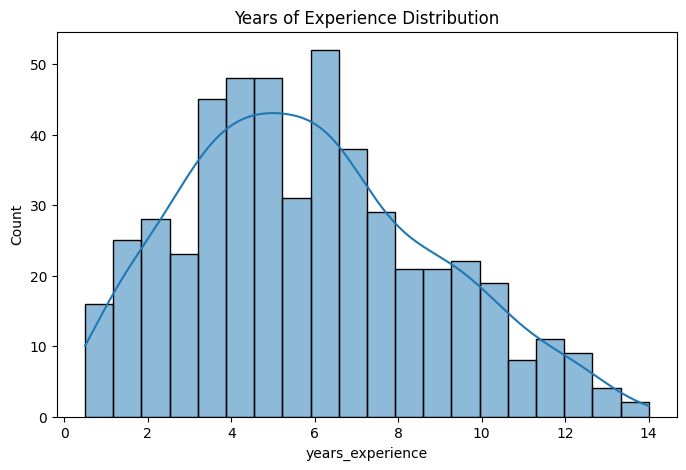

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(freelancer["years_experience"], bins=20, kde=True)
plt.title("Years of Experience Distribution")
plt.show()

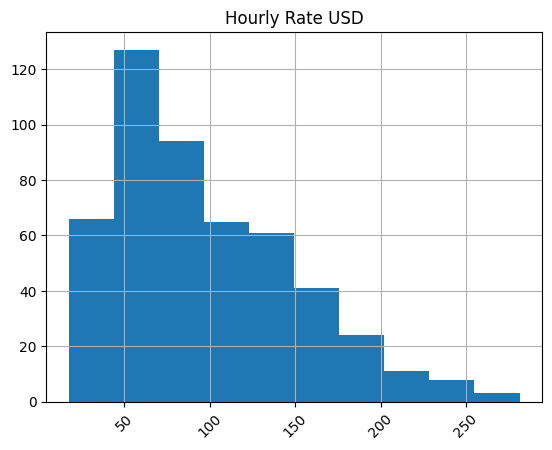

In [23]:
freelancer['hourly_rate_usd'].hist()
plt.xticks(rotation=45)
plt.title('Hourly Rate USD')
plt.show()

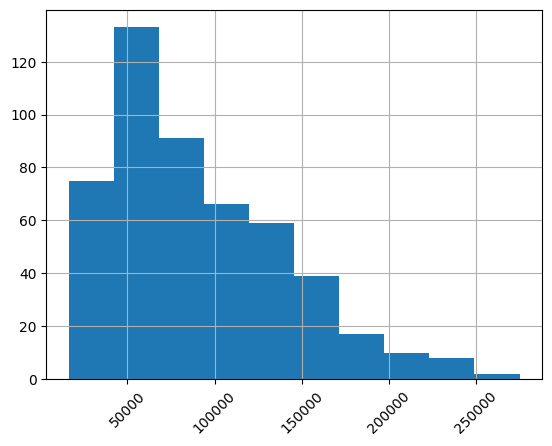

In [20]:
freelancer['annual_income_usd'].hist()
plt.xticks(rotation=45)
plt.show()

# Preprocessing

In [16]:
#handle annual_income_usd column. covert object to numerical columns
freelancer['annual_income_usd']= pd.to_numeric(
    freelancer['annual_income_usd'].replace(r'[$,]', '', regex= True),
    errors= 'coerce'
)

In [17]:
freelancer.describe()

,years_experience,hourly_rate_usd,annual_income_usd
count,500.000000,500.000000,500.000000
mean,5.850000,97.149820,91299.028300
std,2.934779,52.697831,50378.426293
min,0.500000,17.280000,16236.640000
25%,3.600000,55.182500,52694.865000
50%,5.600000,84.445000,78405.365000
75%,7.800000,130.497500,123443.555000
max,14.000000,281.470000,275012.360000


In [19]:
freelancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   freelancer_id      500 non-null    object 
 1   category           500 non-null    object 
 2   primary_skills     500 non-null    object 
 3   years_experience   500 non-null    float64
 4   experience_level   500 non-null    object 
 5   region             500 non-null    object 
 6   country            500 non-null    object 
 7   education          500 non-null    object 
 8   hourly_rate_usd    500 non-null    float64
 9   annual_income_usd  500 non-null    float64
 10  primary_platform   500 non-null    object 
dtypes: float64(3), object(8)
memory usage: 43.1+ KB


In [25]:
all_skills= freelancer['skill_count'] = freelancer['primary_skills'].apply(lambda x: len(x.split(',')))

In [ ]:
all_skills = df['primary_skills'].str.split(',').explode()
top_skills = all_skills.value_counts().head(10).index

In [30]:
freelancer.sample(10)

,freelancer_id,category,primary_skills,years_experience,experience_level,region,country,education,hourly_rate_usd,annual_income_usd,primary_platform,skill_count
103,FL0104,Backend Development,"Java, C#, Go",3.5,mid,Middle East,Israel,Master,83.05,80138.43,Upwork,3
237,FL0238,Web Development,"Angular, Vue.js, Node.js",4.9,mid,Eastern Europe,Ukraine,Self-taught,45.56,41121.00,Freelancer,3
378,FL0379,DevOps,"Kubernetes, Docker, CI/CD",2.9,mid,North America,US,Bachelor,127.87,128316.11,Upwork,3
192,FL0193,Backend Development,"Python, Ruby, C#",7.4,senior,Latin America,Argentina,Bachelor,75.49,66391.49,Direct Client,3
290,FL0291,AI/ML Engineering,"TensorFlow, NLP, Data Science",8.4,senior,Asia Pacific,India,Bachelor,62.35,56812.27,Freelancer,3
391,FL0392,Cybersecurity,"Network Security, Cryptography, Penetration Te...",5.1,senior,Eastern Europe,Poland,Bachelor,107.04,103856.80,Direct Client,3
459,FL0460,Web Development,"HTML/CSS, Node.js, JavaScript",5.9,senior,Africa,Nigeria,Master,47.05,45616.50,Upwork,3
276,FL0277,Backend Development,"C#, Java, Ruby",3.9,mid,Latin America,Mexico,Bachelor,48.90,39615.44,Direct Client,3
124,FL0125,Data Engineering,"Python, SQL, Spark",4.9,mid,North America,US,Bachelor,121.94,112237.52,Direct Client,3
157,FL0158,DevOps,"Kubernetes, Terraform, AWS",3.9,mid,Latin America,Argentina,Master,61.18,52711.84,Upwork,3


In [ ]:
# freelancer.groupby('country')['annual_income_usd'].mean().sort_values(ascending=False)